# 02 - Why naive inversion fails

Lecture section: 3.1-3.5  |  Spine term this tutorial changes: the prior **R** (here we use **none**, R = 0)

$$\hat{x} = \arg\min_x\ \underbrace{D(Ax, y)}_{\mathrm{data\ fidelity}} + \underbrace{R(x)}_{\mathrm{prior}}$$

Before we add any prior, let us see what happens with **pure data-fidelity** inversion:
$R = 0$, so we just try to undo $A$ and match $y$. Our physics $D$ is a **sparse-view, noisy CT**
operator: few angles makes $A$ ill-posed, and a little measurement noise is enough to make the
naive inverse **explode**. This is the motivation for the entire rest of the lecture: we *need* a
prior $R$ to tame the inversion.

In [1]:
import tutorial_common as tc
import deepinv as dinv
import torch

tc.set_seed()

deepinv 0.4.1 | torch 2.9.1 | device cpu


## Step 1 - One ill-posed problem, two measurements (clean vs noisy)

We fix the physics $D$: a **20-angle** CT operator. The clean operator gives us the noiseless
sinogram $y_{\text{clean}} = Ax$; the noisy operator adds Gaussian noise of std $\sigma = 0.05$
to produce $y_{\text{noisy}}$. Same object $x$, same forward map $A$ - the only difference is a
whisper of noise on the measurements.

In [2]:
x = tc.load_object(128)                                  # (1,1,128,128) phantom in [0,1]
phys_clean = tc.ct_physics(angles=20, sigma=0.0)       # noiseless physics
phys_noisy = tc.ct_physics(angles=20, sigma=0.05)      # same A, + measurement noise

y_clean = phys_clean.A(x)        # A(x): deterministic, clean sinogram
y_noisy = phys_noisy(x)          # physics(x): applies the noise model
print(f"sinogram shape {tuple(y_clean.shape)}  (detector cells x angles)")
print(f"measurement noise std added: {(y_noisy - y_clean).std().item():.3f}")

sinogram shape (1, 1, 182, 20)  (detector cells x angles)
measurement noise std added: 0.050


## Step 2 - Naive inversion: it works on clean data, explodes on noisy data

With $R = 0$, "solving" the inverse problem means inverting $A$ to fit $y$. Two ways:

- **FBP** (filtered back-projection): the classical fast inverse for CT.
- **$A^\dagger$** (the least-squares pseudo-inverse): minimizes $\|Ax - y\|^2$ - the purest
  possible "just fit the data, no prior" reconstruction. `deepinv` computes it with an iterative
  solver; by default that solver **stops early** (`max_iter=50`, `tol=1e-4`), which quietly acts
  as a *little* regularization. To see the *genuine* naive inverse we push that regularization
  toward zero (`max_iter=300, tol=1e-10`), letting the solver run to convergence.

We reconstruct **both** measurements with **both** methods (top row = clean, bottom row = noisy):

- On **clean** data both work; the pure $A^\dagger$ even **beats FBP** (it fits the 20 angles
  exactly, while FBP is only approximate).
- On **noisy** data FBP gets streaky, and $A^\dagger$ - which trusts the data completely - is
  **destroyed**, exploding to values far outside $[0,1]$ (watch the colorbars).

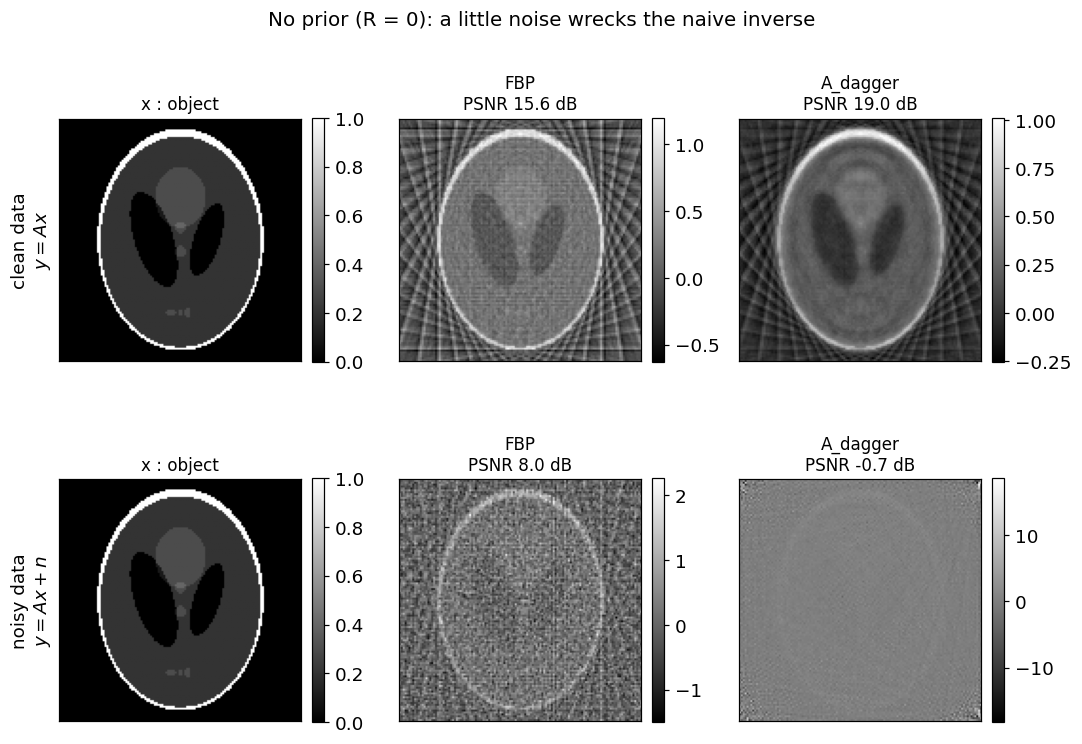

In [3]:
import matplotlib.pyplot as plt

# Push the solver's implicit regularization toward 0 so A_dagger is the genuine,
# unregularized least-squares inverse (run to convergence, not stopped early).
adag_kw = dict(max_iter=300, tol=1e-10)

fbp_clean  = phys_clean.fbp(y_clean)                    # FBP,     clean data
adag_clean = phys_clean.A_dagger(y_clean, **adag_kw)   # A_dagger, clean data
fbp_noisy  = phys_clean.fbp(y_noisy)                    # FBP,     noisy data
adag_noisy = phys_clean.A_dagger(y_noisy, **adag_kw)   # A_dagger, noisy data  (explodes)

# 2 rows (clean / noisy) x 3 cols (object, FBP, A_dagger); each with its own colorbar.
rows = [("clean data\n$y = Ax$",      [x, fbp_clean, adag_clean]),
        ("noisy data\n$y = Ax + n$",  [x, fbp_noisy, adag_noisy])]
names = ["x : object", "FBP", "A_dagger"]

fig, axes = plt.subplots(2, 3, figsize=(10, 7.2))
for r, (row_label, imgs) in enumerate(rows):
    for c, im in enumerate(imgs):
        ax = axes[r, c]
        m = ax.imshow(im.squeeze().cpu(), cmap="gray")
        fig.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(names[c] if c == 0 else tc.title_psnr(names[c], im, x), fontsize=11)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    axes[r, 0].set_ylabel(row_label, fontsize=12)
fig.suptitle("No prior (R = 0): a little noise wrecks the naive inverse", fontsize=13)
fig.tight_layout()
plt.show()

Same operator, same reconstruction method - only the measurements differ by a whisper of noise,
yet the noisy $A^\dagger$ jumps from $[0,1]$ to wildly negative and super-bright values, and its
PSNR is the *worst* of all, precisely because it trusts the noisy data most. Why? Because $A$ has
tiny singular values, and inverting divides by them. Let us measure that.

## Step 3 - The singular value spectrum, the condition number, and the Picard plot

To see *why* inversion explodes, we build the operator $A$ **explicitly** as a matrix (small size
$N = 32$, 30 angles), then take its (thin) SVD $A = U \Sigma V^\top$. We probe one column at a
time by applying $A$ to each unit pixel $e_i$ - the result is the $i$-th column of $A$. We need
this matrix-form $A$ once, purely to *diagnose* the problem; the reconstructions above used the
fast operators.

$A$ here is $m \times n$ with $m > n$ (more detector readings than pixels), so the thin SVD gives
$U \in \mathbb{R}^{m\times n}$, $\Sigma \in \mathbb{R}^{n\times n}$ and $V \in \mathbb{R}^{n\times
n}$, with $U^\top U = V^\top V = I$. The **left** singular vectors $u_i$ (columns of $U$) live in
**measurement space**, the **right** singular vectors $v_i$ (columns of $V$) live in **image
space**, and the pseudo-inverse is $A^\dagger = V\Sigma^{-1}U^\top$. We verify $A = U\Sigma V^\top$
below, then plot the **singular values** two ways - the sorted spectrum (left) and a histogram on
a log axis (right) - so we can see *how many* of them are vanishingly small.

SVD check: ||A - U S V^T||/||A|| = 2.4e-06 | ||U^T U - I|| = 6.5e-05 | ||V^T V - I|| = 6.6e-05
A_mat (1380, 1024) | sigma_max=1.00e+00  sigma_min=8.41e-08
condition number  kappa = sigma_max / sigma_min = 1.2e+07


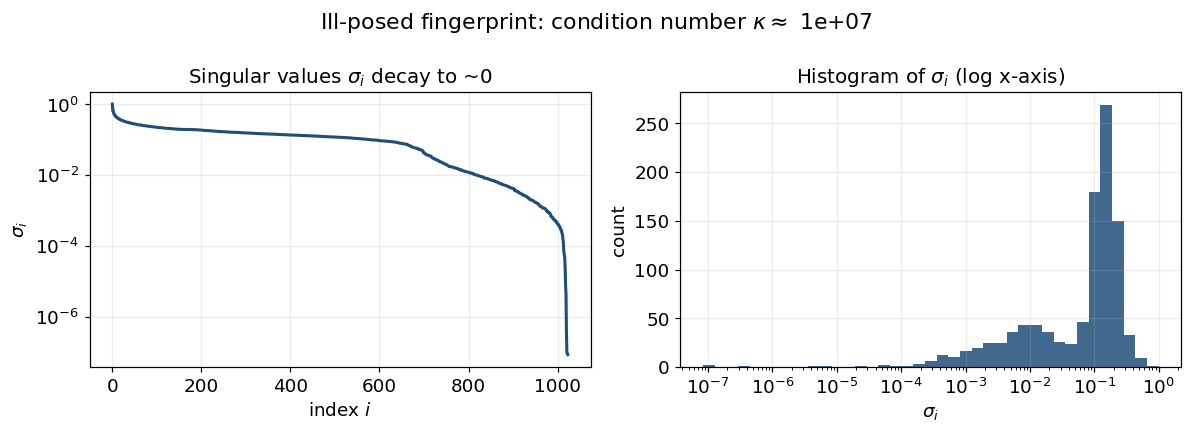

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N, n_angles, sigma = 32, 30, 0.05
p = tc.ct_physics(angles=n_angles, size=N)

# Build A column by column: A e_i = i-th column of A.
cols = []
for i in range(N * N):
    e = torch.zeros(1, 1, N, N, device=tc.DEVICE)
    e.view(-1)[i] = 1.0
    cols.append(p.A(e).reshape(-1))
A_mat = torch.stack(cols, dim=1)                 # (m measurements, n = N*N pixels)
U, S, Vh = torch.linalg.svd(A_mat, full_matrices=False)   # U:(m,n)  S:(n,)  Vh = V^T:(n,n)

# Sanity check that the SVD is well-defined: A = U S V^T and U, V are orthonormal.
rec_err = (A_mat - U @ torch.diag(S) @ Vh).norm() / A_mat.norm()
orth_U = (U.t() @ U - torch.eye(U.shape[1])).norm()
orth_V = (Vh @ Vh.t() - torch.eye(Vh.shape[0])).norm()
print(f"SVD check: ||A - U S V^T||/||A|| = {rec_err:.1e} | ||U^T U - I|| = {orth_U:.1e} | ||V^T V - I|| = {orth_V:.1e}")

# The condition number = sigma_max / sigma_min, computed honestly from the full spectrum.
kappa = (S[0] / S[-1]).item()
print(f"A_mat {tuple(A_mat.shape)} | sigma_max={S[0]:.2e}  sigma_min={S[-1]:.2e}")
print(f"condition number  kappa = sigma_max / sigma_min = {kappa:.1e}")

Snp = S.cpu().numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Left: the sorted spectrum decaying to ~0 (log-y).
ax[0].semilogy(np.arange(Snp.size), Snp, color=tc.PALETTE["A"], lw=2)
ax[0].set(title="Singular values $\\sigma_i$ decay to ~0", xlabel="index $i$", ylabel="$\\sigma_i$")
# Right: histogram of the singular values, log-scaled x-axis, showing a big pile near 0.
bins = np.logspace(np.log10(Snp.min()), np.log10(Snp.max()), 40)
ax[1].hist(Snp, bins=bins, color=tc.PALETTE["A"], alpha=0.85)
ax[1].set_xscale("log")
ax[1].set(title="Histogram of $\\sigma_i$ (log x-axis)", xlabel="$\\sigma_i$", ylabel="count")
fig.suptitle(f"Ill-posed fingerprint: condition number $\\kappa \\approx$ {kappa:.0e}")
fig.tight_layout()
plt.show()

The spectrum tells the whole story. The **condition number** $\kappa = \sigma_{\max}/\sigma_{\min}
\approx 10^7$ - seven orders of magnitude - is the real fingerprint of an ill-posed problem, and
the histogram shows a large pile of singular values bunched near zero. Inverting $A$ means
*dividing* by each $\sigma_i$, so those tiny values are landmines.

The **Picard plot** shows exactly when they go off. The least-squares solution is
$\hat{x} = \sum_i \frac{u_i^\top y}{\sigma_i}\, v_i$, so each measurement coefficient $u_i^\top y$
gets **divided by** $\sigma_i$:

- The **clean** signal's coefficients $|u_i^\top y|$ *decay* alongside $\sigma_i$ (the Picard
  condition) - the true object lives in the well-seen directions.
- **Noise** does *not* decay: at large $i$, $|u_i^\top y|$ is dominated by noise of size
  $\sim\sigma$, and dividing by a tiny $\sigma_i$ sends $|u_i^\top y| / \sigma_i$ to enormous
  values. Those blown-up terms are what destroyed $A^\dagger$ above.

We build $y$ at the same small size, add the same noise, and plot the Picard coefficients.

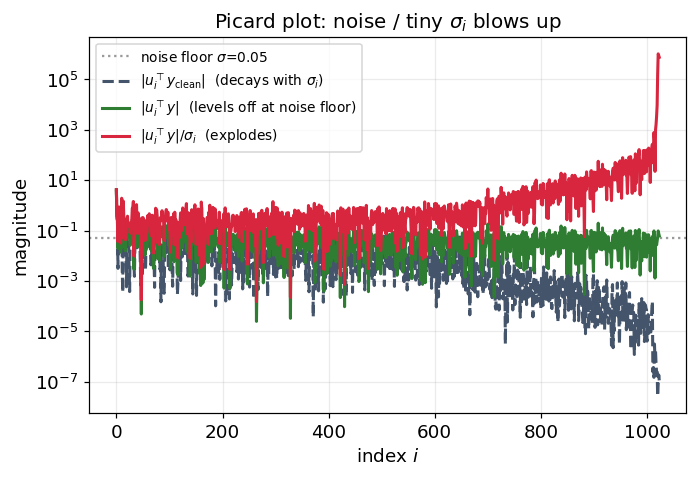

clean |u^T y| last index: 1.2e-07   ->   /sigma_i: 1.4e+00  (bounded)
noisy |u^T y| last index: 6.2e-02   ->   /sigma_i: 7.3e+05  (blown up)


In [5]:
x_small = tc.load_object(N).reshape(-1)
y_small_clean = A_mat @ x_small
tc.set_seed()                                    # reproducible noise
y_small = y_small_clean + sigma * torch.randn_like(y_small_clean)

coeff_clean = (U.t() @ y_small_clean).abs()      # |u_i^T y_clean|  (clean measurement coefficients)
coeff = (U.t() @ y_small).abs()                  # |u_i^T y|        (noisy measurement coefficients)
picard = coeff / S                               # |u_i^T y| / sigma_i  (the division that explodes)
idx = torch.arange(S.numel())

# The Picard plot. The three measurement-coefficient curves are the whole story:
#   clean |u_i^T y| keeps decaying alongside sigma_i (the Picard condition holds), but
#   noisy |u_i^T y| flattens out at the noise floor ~sigma and stops decaying,
# so dividing that flat noisy curve by a vanishing sigma_i is exactly what explodes.
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.axhline(sigma, color=tc.PALETTE["gray"], ls=":", lw=1.5, label=f"noise floor $\\sigma$={sigma}")
ax.semilogy(idx, coeff_clean, color=tc.PALETTE["slate"], lw=2, ls="--",
            label="$|u_i^\\top y_{\\mathrm{clean}}|$  (decays with $\\sigma_i$)")
ax.semilogy(idx, coeff, color=tc.PALETTE["y"], lw=2,
            label="$|u_i^\\top y|$  (levels off at noise floor)")
ax.semilogy(idx, picard, color=tc.PALETTE["x"], lw=2,
            label="$|u_i^\\top y| / \\sigma_i$  (explodes)")
ax.set(title="Picard plot: noise / tiny $\\sigma_i$ blows up", xlabel="index $i$", ylabel="magnitude")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
print(f"clean |u^T y| last index: {coeff_clean[-1]:.1e}   ->   /sigma_i: {(coeff_clean / S)[-1]:.1e}  (bounded)")
print(f"noisy |u^T y| last index: {coeff[-1]:.1e}   ->   /sigma_i: {picard[-1]:.1e}  (blown up)")

## Takeaway

The operator $A$ has singular values that decay to ~0, and the naive (least-squares) inverse
divides the measurements - **noise included** - by those tiny values, so the reconstruction
explodes. Pure data-fidelity ($R = 0$) is not enough: we need a **prior $R$** to regularize the
inversion. That is what the rest of the lecture builds, one smarter $R$ at a time.